# Lecture 7 — Model Answer
## Heatmap & Waterfall: Netflix Catalogue


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print('Genres:', df['genre'].value_counts().head(8))
print('\nCountries:', df['country'].value_counts().head(8))
print('\nRatings:', df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade


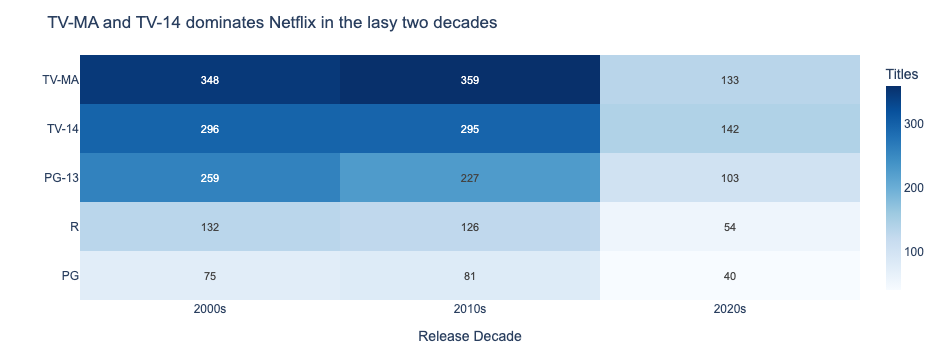

In [37]:
# ── Data prep ─────────────────────────────────────────────────────────────────
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

# Filter to the five most common ratings only
top_ratings = ['TV-MA', 'TV-14', 'PG-13', 'R', 'PG']
df_heat = df[df['rating'].isin(top_ratings)].copy()

# Pivot: ratings on y, decades on x, count of titles as values
pivot = (
    df_heat.groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
    .pivot(index='rating', columns='decade', values='count')
    .fillna(0)
)

# Sort ratings by total volume — most common at top
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# ── Step 1: Plotly Express base chart ─────────────────────────────────────────
fig = px.imshow(
    pivot,
    color_continuous_scale='Blues',    # sequential — counts are one-directional
    aspect='auto',
    text_auto=True,                    # show count in each cell
    labels={'color': 'Titles'},
    title='TV-MA and TV-14 dominates Netflix in the lasy two decades',
)

# ── Step 2: Customisation ─────────────────────────────────────────────────────

fig.update_traces(
    textfont=dict(size=11),
    hovertemplate='<b>%{y}</b> — %{x}<br>Titles: %{z}<extra></extra>',
)

fig.update_layout(
    font=dict(family='Arial', size=12),
    coloraxis_colorbar=dict(title='Titles', thickness=15),
    margin=dict(l=80, r=40, t=55, b=60),
    paper_bgcolor='white',
)
fig.update_xaxes(
    title='Release Decade',
    tickmode='array',
    tickvals=list(pivot.columns),
    ticktext=list(pivot.columns),
)
fig.update_yaxes(title='')

fig.show()


## Task 2 — Waterfall: Movie library growth by year


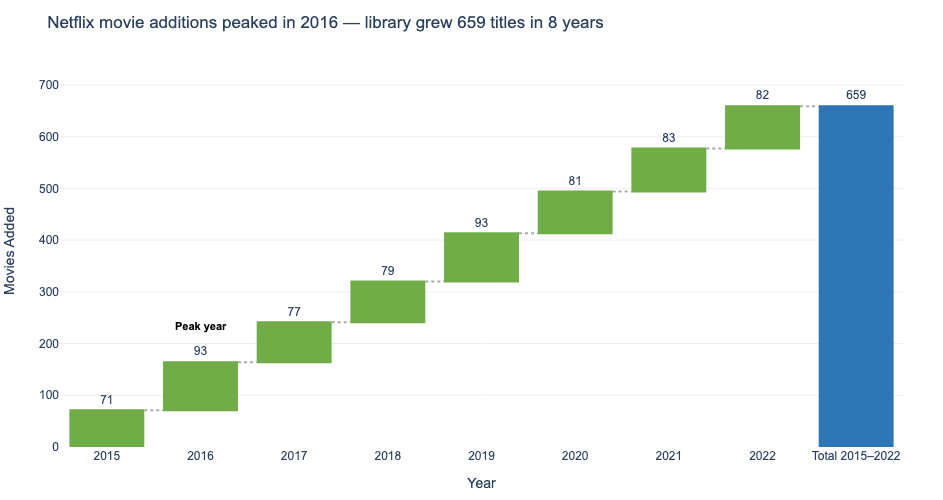

In [32]:
# ── Data prep ─────────────────────────────────────────────────────────────────
movies = df[df['type'] == 'Movie'].copy()

adds = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='new_titles')
)
adds = adds.loc[adds['added_year'].between(2015, 2022)].copy()

cumulative = adds['new_titles'].sum()

x_vals  = adds['added_year'].astype(str).tolist() + ['Total 2015–2022']
y_vals  = adds['new_titles'].tolist() + [cumulative]
measure = ['relative'] * len(adds) + ['total']
# relative = each bar stacks on the previous (incremental additions)
# total    = final bar drops to zero and shows the full cumulative height

# ── Chart ────────────────────────────────
trace = go.Waterfall(
    x=x_vals,
    y=y_vals,
    measure=measure,
    connector=dict(line=dict(color='#AAAAAA', dash='dot')),
    increasing=dict(marker_color='#70AD47'),   # green: additions
    totals=dict(marker_color='#2E75B6'),        # blue: cumulative total bar
    texttemplate='%{y:,}',
    textposition='outside',
)

fig = go.Figure(data=[trace])

# ── Customisation ─────────────────────────────────────────────────────────────
# Annotate the peak year bar directly
# Year with the largest single addition — annotate this bar
peak_year  = adds.loc[adds['new_titles'].idxmax(), 'added_year']
peak_idx = adds['added_year'].astype(str).tolist().index(str(peak_year))
# Cumulative total up to and including peak year — this is where the top of the bar sits
peak_cumulative_y = adds.loc[adds['added_year'] <= peak_year, 'new_titles'].sum()

fig.add_annotation(
    x=peak_idx,
    y=peak_cumulative_y + 70,          # just above the top of the bar
    text='<b>Peak year</b>',
    font=dict(color='black', size=11, family='Arial'),
    showarrow=False
)

fig.update_layout(
    title=f'Netflix movie additions peaked in {peak_year} — library grew {cumulative:,} titles in 8 years',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    showlegend=False,
    margin=dict(l=60, r=40, t=55, b=40),
    height=500,
)
fig.update_xaxes(title='Year', showgrid=False)
fig.update_yaxes(
    title='Movies Added',
    gridcolor='#EEEEEE',
    range=[0, cumulative * 1.15],      # explicit headroom so nothing gets clipped
)

fig.show()